<a href="https://colab.research.google.com/github/Dov-elhacker/regression-analysis/blob/main/Copy_of_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
#Upload and load data
df = pd.read_csv("car_price.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [ ]:
#Inspect
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(72435, 10)
model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object
model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,68813.0,2017.077660,2.099474,1996.0,2016.00,2017.0,2019.00,2020.0
price,68814.0,16583.919261,9304.412707,495.0,10167.25,14495.0,20359.75,145000.0
mileage,68813.0,23179.439539,21347.569657,1.0,7199.00,17521.0,32478.00,323000.0
tax,68814.0,116.930421,64.081931,0.0,30.00,145.0,145.00,580.0
mpg,68814.0,55.836352,17.043643,0.3,47.90,55.4,62.80,470.8
engineSize,68813.0,1.635373,0.561734,0.0,1.20,1.6,2.00,6.6


In [ ]:
#Clean and impute data
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=['price'])
df = df.drop_duplicates()

numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'enginesize']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

cat_cols = ['transmission', 'fueltype', 'make']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

model           3443
year               0
price              0
transmission       0
mileage            0
fueltype           0
tax                0
mpg                0
enginesize         0
make               0
dtype: int64


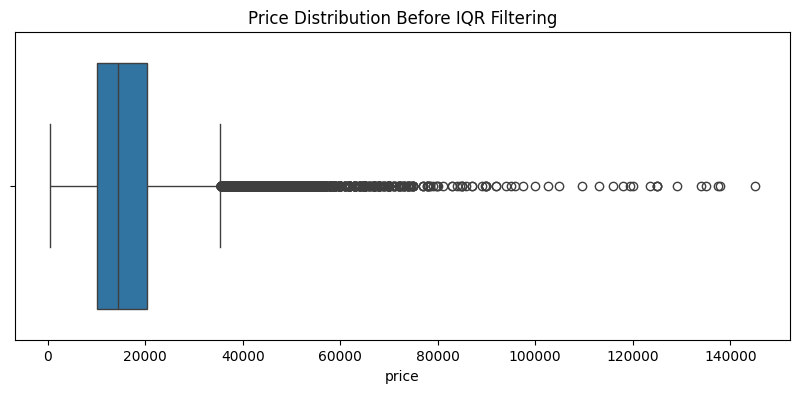

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'])
plt.title('Price Distribution Before IQR Filtering')
plt.show()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the data
df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()
df_no_outliers.reset_index(drop=True, inplace=True)

In [ ]:
# One-Hot Encode
df_encoded = pd.get_dummies(df_no_outliers, columns=[c for c in cat_cols if c in df.columns], drop_first=True)

if 'model' in df_encoded.columns:
    df_encoded.drop(columns=['model'], inplace=True)

print(df_encoded.shape)

(65848, 19)


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (52678, 18)
Testing set shape: (13170, 18)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features (Gradient Descent requires scaling to prevent divergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
class LinearRegressionML:
    def __init__(self):
        self.B0 = 0.0
        self.B1 = None
        self.MSE = None

    def fit(self, X, y, learning_rate=0.01, epochs=1000):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        n_samples, n_features = X.shape
        self.B1 = np.zeros(n_features)

        for _ in range(epochs):
            y_hat = self.B0 + X @ self.B1
            error = y_hat - y

            dB0 = (2 / n_samples) * np.sum(error)
            dB1 = (2 / n_samples) * (X.T @ error)

            self.B0 -= learning_rate * dB0
            self.B1 -= learning_rate * dB1

        final_error = y - (self.B0 + X @ self.B1)
        self.MSE = np.mean(final_error ** 2)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.B0 + X @ self.B1

In [ ]:
from sklearn import metrics

# Initialize the Linear Regression Model
ML_model = LinearRegressionML()

# Final Train using the full scaled 80% training set
ML_model.fit(X_train_scaled, y_train, learning_rate=0.1, epochs=200)

# Predict prices for the scaled 20% test set
y_pred = ML_model.predict(X_test_scaled)

# Model Evaluation Output
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("\n--- Task 4: Final Linear Regression Performance (Test Set) ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


--- Task 4: Final Linear Regression Performance (Test Set) ---
R-squared (R2) Score: 0.7762
Mean Absolute Error (MAE): 2448.69
Mean Squared Error (MSE): 10553181.30
Root Mean Squared Error (RMSE): 3248.57


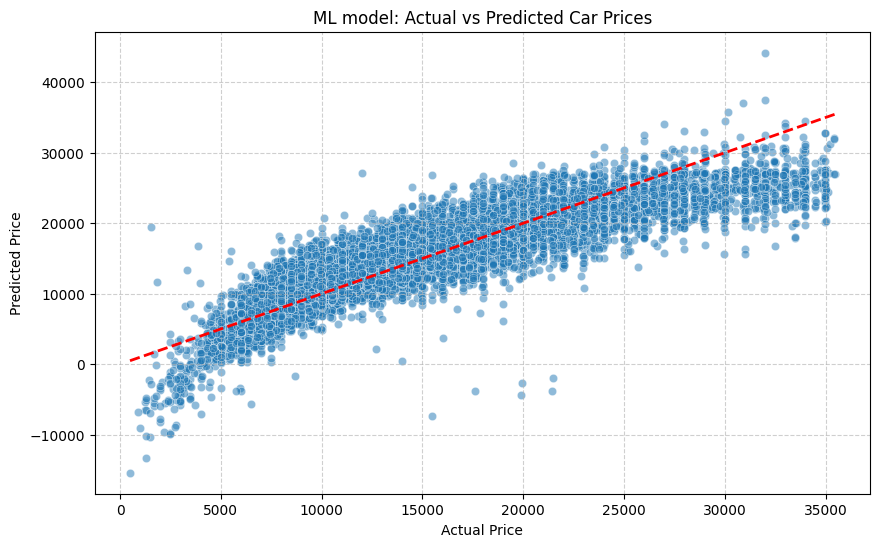

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('ML model: Actual vs Predicted Car Prices')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
class LinearRegressionNumerical:
    def __init__(self):
        self.beta = None
        self.MSE = None

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        X_with_intercept = np.c_[np.ones(X.shape[0]), X]

        # Normal Equation: beta = (X^T * X)^-1 * X^T * y
        self.beta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

        y_hat = self.predict(X)
        e = y - y_hat
        SSE = np.sum(e**2)
        self.MSE = SSE / (len(X) - X_with_intercept.shape[1])

    def predict(self, X):
        X = np.array(X, dtype=float)
        X_with_intercept = np.c_[np.ones(X.shape[0]), X]
        return X_with_intercept @ self.beta

In [ ]:
N_model = LinearRegressionNumerical()
N_model.fit(X_train, y_train)

y_pred_stat = N_model.predict(X_test)
print(f"Numerical Model MSE: {N_model.MSE:.2f}")

Numerical Model MSE: 10638097.29


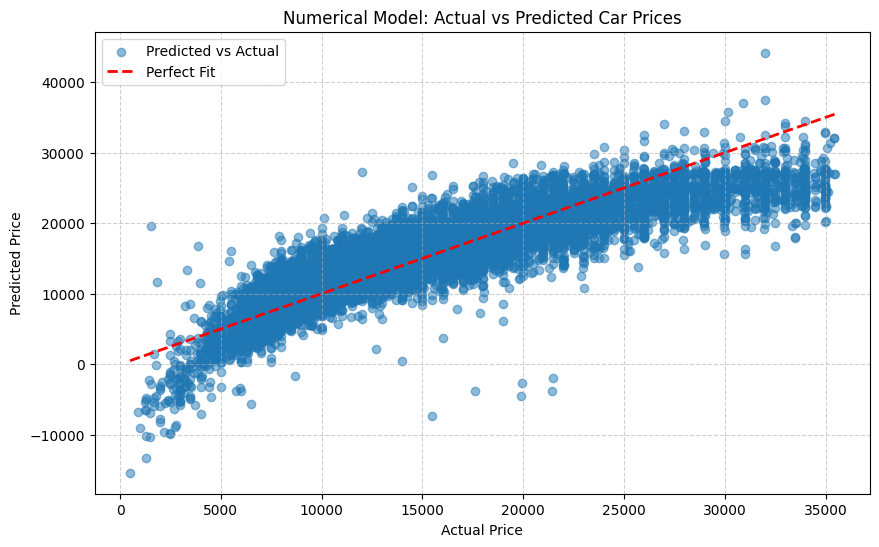

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stat, alpha=0.5, label='Predicted vs Actual')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Numerical Model: Actual vs Predicted Car Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
class LinearRegressionStat:

  def __init__(self):
    self.B0 = None
    self.B1 = None
    self.MSE = None

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)

    x_bar = X.mean()
    y_bar = y.mean()

    SXX = np.sum(X**2) - len(X) * x_bar**2
    SXY = np.sum(X * y) - len(X) * x_bar * y_bar

    self.B1 = SXY / SXX
    self.B0 = y_bar - self.B1 * x_bar

    y_hat = self.predict(X)
    e = y - y_hat
    SSE = np.sum(e**2)
    self.MSE = SSE / (len(X) - 2)

  def predict(self, X):
    X = np.array(X)
    return self.B0 + self.B1 * X

Correlation with Price:
price         1.000000
year          0.555685
enginesize    0.511476
tax           0.380911
mpg          -0.272232
mileage      -0.448136
Name: price, dtype: float64


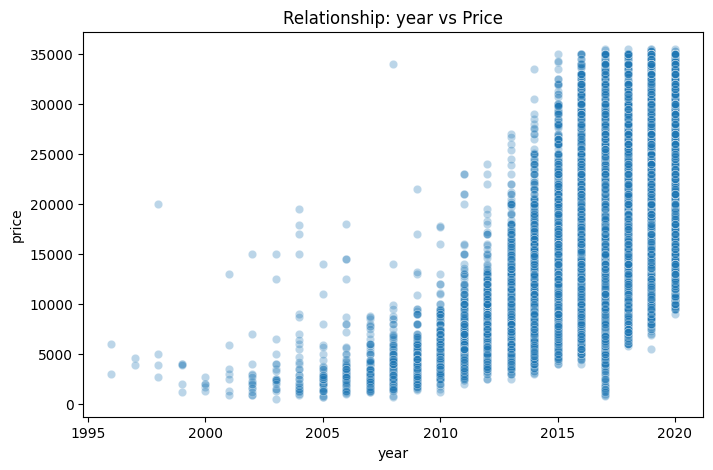

In [ ]:
# Calculate correlation matrix for numeric columns
correlations = df_encoded.select_dtypes(include=[np.number]).corr()['price'].sort_values(ascending=False)
print("Correlation with Price:")
print(correlations)

# Visualize the top feature vs Price
top_feature = correlations.index[1] # Index 0 is 'price' itself
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_encoded, x=top_feature, y='price', alpha=0.3)
plt.title(f'Relationship: {top_feature} vs Price')
plt.show()

Statistical Model (Single Feature: year) MSE: 32483589.14


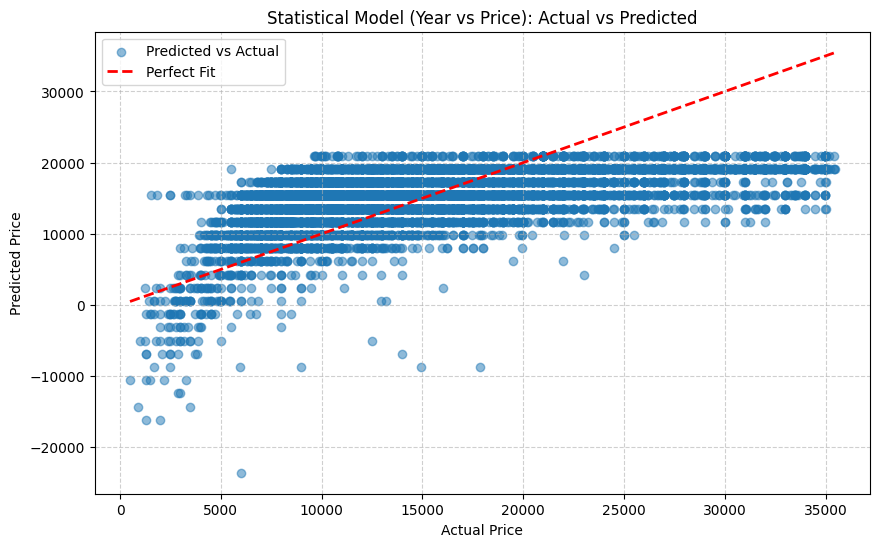

In [ ]:
# Using only the top feature 'year' for simple linear regression
X_train_single = X_train["year"]
X_test_single = X_test["year"]

# Initialize and fit the Statistical model
St_model = LinearRegressionStat()
St_model.fit(X_train_single, y_train)

y_pred_stat = St_model.predict(X_test_single)
print(f"Statistical Model (Single Feature: year) MSE: {St_model.MSE:.2f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stat, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Statistical Model (Year vs Price): Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()